<a href="https://colab.research.google.com/github/UW-CTRL/lmc-exercises/blob/main/01a_dynamics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dynamics and trajectories
In this notebook, you will familiarize yourself with setting up a dynamical system, generating trajectories.
In this notebook (notebook 1a), we will implement everything in `numpy`. In the next notebook (notebook 1b), we will use `JAX` and repeat the same computation and more using the additional functionalities of `JAX` over `numpy`.



## 1. Dynamics and trajectories

First, let's import the relevant packages

In [121]:
import abc
from typing import Callable
import matplotlib.pyplot as plt
import numpy as np
import math

Let's now define a base class for representing the dynamics of a system.

Carefully review the Dynamics class below, as you'll build upon and use it in the following sections.

In [122]:
class Dynamics(metaclass=abc.ABCMeta):
    """Abstract base class for dynamical systems."""

    dynamics_func: Callable[[np.ndarray, np.ndarray, float], np.ndarray]
    state_dim: int
    control_dim: int

    def __init__(
        self,
        dynamics_func: Callable[[np.ndarray, np.ndarray, float], np.ndarray],
        state_dim: int,
        control_dim: int,
    ):
        """Initializes the Dynamics object.

        Args:
            dynamics_func: A callable representing the dynamics function.
            state_dim: The dimension of the state space.
            control_dim: The dimension of the control space.
        """
        self.dynamics_func = dynamics_func
        self.state_dim = state_dim
        self.control_dim = control_dim

    def __call__(
        self, state: np.ndarray, control: np.ndarray, time: float = 0.0
    ) -> np.ndarray:
        """Evaluates the dynamics function at a given state, control, and time.
        For continuous time dynamics, we have x_dot = f(x, u, t)
        For discrete time dynamics, we have x_{k+1} = f(x_k, u_k, t_k)

        Args:
            state: The current state.
            control: The current control input.
            time: The current time (optional, defaults to 0).

        Returns:
            The next state.
        """
        return self.dynamics_func(state, control, time)

###  (a) Discretizing Continuous-Time Dynamics

To simulate or control physical systems on a computer, we often need to convert continuous-time dynamics into discrete-time dynamics by integrating over a fixed time step $\Delta t$.
In this section, you will derive discrete-time dynamics from continuous-time models using two different numerical integration methods:
- Euler integration (a simple, first-order method)
- Runge-Kutta integration (specifically, the more accurate fourth-order RK4 method)
Implement both integration techniques to obtain the discrete-time dynamics.


#### (i) Implement Euler integation to obtain the discrete-time dynamics.

In [123]:
def euler_integrate(
    dynamics: Callable[[np.ndarray, np.ndarray, float], np.ndarray], dt: float
) -> Callable[[np.ndarray, np.ndarray, float], np.ndarray]:
    """
    Implement Euler integration for discrete-time dynamics.

    Args:
        dynamics: A callable representing the continuous-time dynamics function.
        dt: The time step for integration.

    Returns:
        A callable representing the discrete-time dynamics using Euler integration.
    """

    # zero-order hold
    def integrator(x: np.ndarray, u: np.ndarray, t: float) -> np.ndarray:

        # TODO: Implement Euler integration here
        ###### add your code here
        x_next = x + dynamics(x,u,t) * dt
        return x_next
        ###### end of add your code here


    return integrator

#### (ii) Implement runge-Kutta integration to obtain the discrete-time dynamics.

In [124]:
def runge_kutta_integrate(
    dynamics: Callable[[np.ndarray, np.ndarray, float], np.ndarray], dt: float
) -> Callable[[np.ndarray, np.ndarray, float], np.ndarray]:
    """
    Implement Runge-Kutta integration for discrete-time dynamics.

    Args:
        dynamics: A callable representing the continuous-time dynamics function.
        dt: The time step for integration.

    Returns:
        A callable representing the discrete-time dynamics using Runge-Kutta integration.
    """

    # zero-order hold
    def integrator(x: np.ndarray, u: np.ndarray, t: float) -> np.ndarray:

        # TODO: Implement Runge-Kutta integration here
        ###### add your code here
        dt2 = dt/2 # pre-compute dt/2 for efficiency
        k1 = dynamics(x, u, t)
        k2 = dynamics(x + dt2*k1, u, t + dt2)
        k3 = dynamics(x + dt2*k2, u, t + dt2)
        k4 = dynamics(x + dt*k3, u, t + dt)
        x_next = x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        return x_next
        ###### end of add your code here

    return integrator


### (b) Defining the Dynamically Extended Unicycle Dynamics
In this section, you will work with the dynamically extended unicycle model.

Your task is to use the previously defined `Dynamics` class to construct the continuous-time dynamics for this model.

The continuous-time state vector is given by
$$
    \mathbf{x} = \begin{bmatrix}
        x \\ y \\ \theta \\ v
    \end{bmatrix}
$$
where $x$, $y$ represent position, $\theta$ is the heading angle, and $v$ is the velocity.

The control input is
$$
    \mathbf{u} = \begin{bmatrix}
        \omega \\ a
    \end{bmatrix}
$$
where $\omega$ is the turn rate and $a$ is the acceleration.

The continuous-time dynamics can be written as:
$$
    \dot{\mathbf{x}} = \begin{bmatrix}
        \dot{x} \\ \dot{y} \\ \dot{\theta} \\ \dot{v}
    \end{bmatrix} =
    \begin{bmatrix}
        v\cos\theta \\ v\sin\theta \\ \omega \\ a
    \end{bmatrix}
$$
Implement this dynamics function, where the state derivative is determined by the current state and control input.

In [125]:
def unicycle_dynamics_func(state, control, time=0):
    """
    Define the unicycle dynamics equations here.

    Args:
      state: The current state of the unicycle (x, y, theta, v).
      control: The control input (omega, a).
      time: The current time (optional).

    Returns:
      The time derivative of the state (dot_x, dot_y, dot_theta, dot_v).
    """

    # TODO: Implement the unicycle dynamics
    ###### add your code here
    x, y, theta, v = state
    omega, a = control
    x_dot = v*np.cos(theta)
    y_dot = v*np.sin(theta)
    theta_dot = omega
    v_dot = a
    return np.array([x_dot, y_dot, theta_dot, v_dot])
    ###### end of add your code here



### (c) Simulate discrete-time dynamics

Now, we can construct *discrete time* dynamics using the different intergation schemes, and simulate it over some horizon.

First, set up the discrete-time dynamics


In [126]:
dt = 0.1

# set up the continuous time dynamics
state_dim = 4
control_dim = 2
continuous_dynamics = Dynamics(unicycle_dynamics_func, state_dim, control_dim)

# set up the discrete time dynamics (Euler integration)
discrete_dynamics_euler = Dynamics(
    euler_integrate(continuous_dynamics, dt), state_dim, control_dim
)

# set up the discrete time dynamics (Runge-Kutta integration)
discrete_dynamics_rk = Dynamics(
    runge_kutta_integrate(continuous_dynamics, dt), state_dim, control_dim
)

Implement the `simulate_dynamics` function to compute the sequence of future states for a system, given a set of discrete-time dynamics, an initial state, and a sequence of control inputs.

Your implementation should make use of `jax.lax.scan` to efficiently iterate the dynamics function over the control sequence.

The returned trajectory should include the initial state as its first element.

In [127]:
def simulate_dynamics(
    dynamics: Callable[[np.ndarray, np.ndarray, float], np.ndarray],
    initial_state: np.ndarray,
    control_sequence: np.ndarray,
    dt: float,
) -> np.ndarray:
    """
    Simulate the discrete-time dynamics over a given time horizon.

    Args:
        dynamics: A callable representing the discrete-time dynamics function.
        initial_state: The initial state of the system.
        control_sequence: A sequence of control inputs for each time step.
        dt: The time step size.

    Returns:
        An array containing the state trajectory over the time horizon.
    """
    # TODO: Implement dynamics simulation here
    ###### add your code here
    n_timesteps = control_sequence.shape[1]
    xs = np.zeros((state_dim, n_timesteps))
    xs[:,0] = initial_state
    for i in range(n_timesteps-1):
        x = xs[:,i]
        u = control_sequence[:,i]
        xs[:,i+1] = dynamics(x, u) # uses discrete-time dynamics (assumese time-invariance)
    return xs.T
    ###### end of add your code here


In [128]:
n_ = 10
for i in range(n_-1):
    print(i)

0
1
2
3
4
5
6
7
8


### (d) Compare integration schemes


#### (i) Simulate Trajectories

In this task, you will simulate the system's dynamics using a constant control input $u_0$ over a duration of 5 seconds. You will explore various values for the integration timestep $\Delta t$ and compare the resulting trajectories.

Specifically, plot the simulated trajectories for both integration schemes (Euler and Runge-Kutta) using the following timestep values: $0.01, 0.05, 0.1, 0.2, 0.4, 0.5$.

Display all resulting trajectories together on the same plot for easier comparison.

Use the following initial state and constant control input throughout the simulation:
- $u_0 = [2,\, 1]^T$
- $x_0 = [0,\, 0,\, 0,\, 0]^T$


In [129]:
# plotting helper function
def plot_trajectory(trajectory, integration_name, linestyle, color, linewidth=3):
    plt.plot(
        trajectory[:, 0],
        trajectory[:, 1],
        linestyle=linestyle,
        color=color,
        label=f"{integration_name}",
        linewidth=linewidth,
    )
    plt.grid(alpha=0.3)

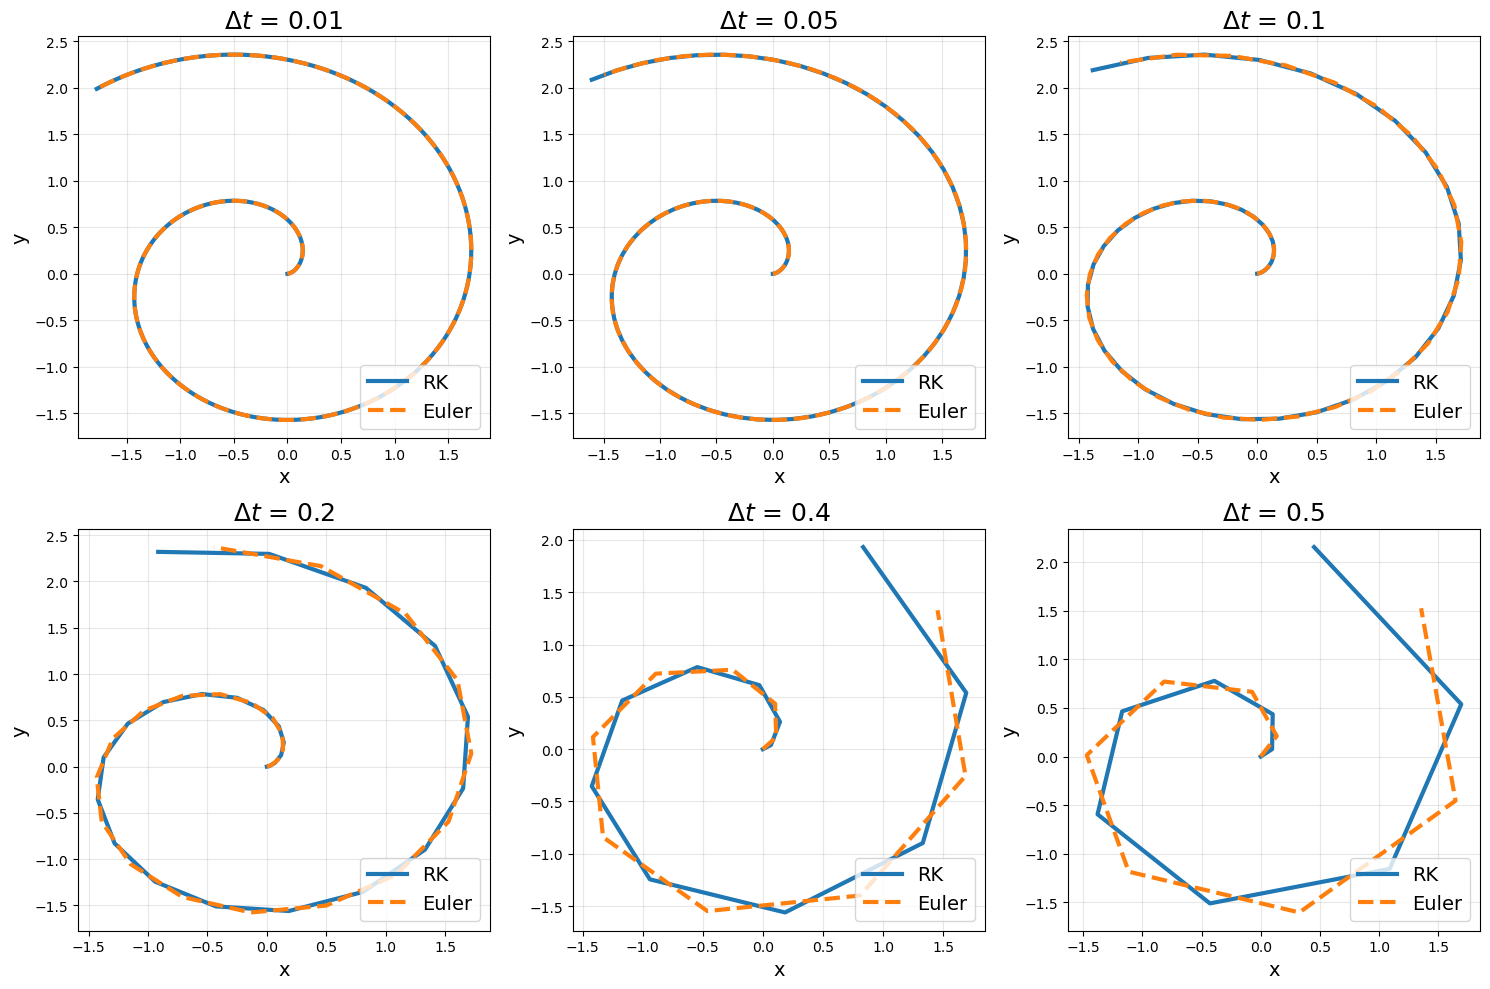

In [130]:
initial_state = np.array([0.0, 0.0, 0.0, 0.0])
control = np.array([2.0, 1.0])  # constant control over the entire horizon
dts = [0.01, 0.05, 0.1, 0.2, 0.4, 0.5]
time_horizon = 5  # seconds
integration_names = ["RK", "Euler"]
integration_funcs = [runge_kutta_integrate, euler_integrate]
linestyles = ["-", "--"]
colors = ["C0", "C1"]
linewidth = 3
fontsize = 18

grid_size = max(1, math.ceil(len(dts) / 3)), min(3, len(dts))

plt.figure(figsize=(15, 5 * grid_size[0]))
for integration_func, integration_name, linestyle, color in zip(
    integration_funcs, integration_names, linestyles, colors
):
    for i, dt in enumerate(dts):
        plt.subplot(*grid_size, i + 1)

        # TODO: Implement the dynamics simulation here and plot the trajectory
        ###### add your code here

        # get control sequence
        n_timesteps = int(time_horizon/dt)
        control_sequence = np.tile(control, (n_timesteps, 1)).T

        # get discrete dynamics
        # continuous_dynamics, state_dim and control_dim are defined in earlier cells
        dynamics = Dynamics(integration_func(continuous_dynamics, dt), state_dim, control_dim)
        trajectory = simulate_dynamics(dynamics, initial_state, control_sequence, dt)
    
        # plot trajectory
        plot_trajectory(trajectory, integration_name, linestyle, color)

        ###### end of add your code here

        plt.legend(fontsize=fontsize - 4, loc="lower right")
        plt.title(f"$\\Delta t$ = {dt}", fontsize=fontsize)
        plt.xlabel("x", fontsize=fontsize - 4)
        plt.ylabel("y", fontsize=fontsize - 4)
    plt.tight_layout()


Congratulations! You have just learned the basics of defining a set of dynamics, extracting the discrete-time version of them, and simulating the dynamics over a time horizon.